# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**1. Business Objectives**
The dealership wants to figure out what drives used car prices so they can buy and price their inventory smarter. My goal is to find the top features that impact price and give them a few solid, data-backed recommendations to improve their strategy.

**2. Assess Situation**
I have a dataset from Kaggle with about 426K used car listings. I'll be using Python, pandas, and scikit-learn to analyze it. The main risks are messy data, missing values, or weird outliers (like $1M cars) throwing off the analysis, so I'll need to clean it up carefully first.

**3. Data Mining Goals**
I'm going to treat this as a regression problem. I want to build models (like Linear Regression, Ridge, or Lasso) to predict listing prices based on car features. Success means building a model with a solid R² score and clearly identifying which features (like year, mileage, or condition) matter most to the price.

**4. Project Plan**
| Phase | Description | 
|-------|-------------|
| **Data Understanding** | Load data, explore distributions, identify quality issues, assess feature relevance |
| **Data Preparation** | Handle missing values, remove outliers, encode categoricals, extract features, scale numerics |
| **Modeling** | Train Linear Regression, Ridge, and Lasso models with cross-validation and hyperparameter tuning |
| **Evaluation** | Compare model performance (MSE), analyze feature coefficients, validate findings against business intuition |
| **Deployment** | Summarize findings in a report with clear recommendations for the dealership |


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [129]:
# datetime
import datetime

# Data manipulation
import pandas as pd
import numpy as np
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Pipelines
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Feature Selection and Dimensionality Reduction
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Clustering (just in case you want to segment vehicles!)
from sklearn.cluster import KMeans

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [130]:
vehicles = pd.read_csv("data/vehicles.csv")
vehicles.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [131]:
# Check for missing values in each column
print(vehicles.isnull().sum())

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64


#### Handling Missing Data

An inspection of the dataset reveals significant missing data (`NaN`) across several columns. To ensure our model trains effectively without introducing unnecessary noise, we will use a multi-tiered approach, leveraging the relationships between features to heal the data where possible:

1. **Drop Severely Sparse Columns:**
   Columns missing a majority of their data provide little predictive value and cannot be reliably dropped (e.g., `size` is missing >70% of its data). We will drop it entirely.

2. **Drop Rows for Crucial, Near-Complete Columns:**
   For critical numerical features like `year` and `odometer` that are missing less than 1% of their data, we will drop the rows containing nulls. With ~426,000 records, the loss of a few thousand rows is negligible.

3. **Data Imputation:**
   Rather than blindly filling missing categoricals, we will leverage the relationships between columns to make an educated guesses:
   * **Condition via Title Status:** If a car's `condition` is missing, but its `title_status` is `salvage` or `parts only`, we can confidently impute the `condition` as `salvage`. If the title is `rebuilt`, we will impute `fair`.
   * **Specs via Car Model:** We can group the data by the car's `model` (e.g., "F-150") to highly accurately impute missing values for `manufacturer`, `cylinders`, `fuel`, and `drive` by filling them with the **mode** (most common value) for that specific model.

4. **Fill Remaining Categoricals with "Unknown":**
   For any remaining categorical features with missing data (e.g., `paint_color`), we will fill the missing values with the string `"other"`. This allows the model to treat the absence of data as its own category, which can act as a predictive signal for the vehicle's price.



In [132]:
vehicles.nunique()

id              426880
region             404
price            15655
year               114
manufacturer        42
model            29649
condition            6
cylinders            8
fuel                 5
odometer        104870
title_status         6
transmission         3
VIN             118246
drive                3
size                 4
type                13
paint_color         12
state               51
dtype: int64


To avoid the "curse of dimensionality" and prevent our model from crashing, we will use four different strategies to process our categorical columns:

1. **Drop Identifiers (`id`, `VIN`):** 
   These are unique to each car and have no predictive value. We will drop them entirely.
   
2. **Ordinal Encoding (`condition`, `cylinders`):** 
   Because these categories have a natural hierarchy (e.g., *fair < good < excellent*), we will map them to ordered numbers (1, 2, 3). This saves space and allows the model to learn their direct relationship to the target price.
   
3. **One-Hot Encoding (`fuel`, `title_status`, `transmission`, `drive`, `type`, `paint_color`, `state`):** 
   For nominal columns with no inherent order and very few unique categories, we will use standard One-Hot Encoding.

4. **Target Encoding (`manufacturer`, `model`, `region`):** 
   For nominal columns with thousands of unique values (like the 29,000+ car models), One-Hot Encoding would create too many columns. Instead, we will bucket rare values into an "Other" category or replace the string with the historical average price for that category (Target Encoding).

Additionally, to make our model more robust and easier to interpret, we will transform the `year` column into a new `car_age` feature (calculated as `current_year - year`). Car age provides a much more direct and intuitive measure of depreciation than the raw manufacturing year.


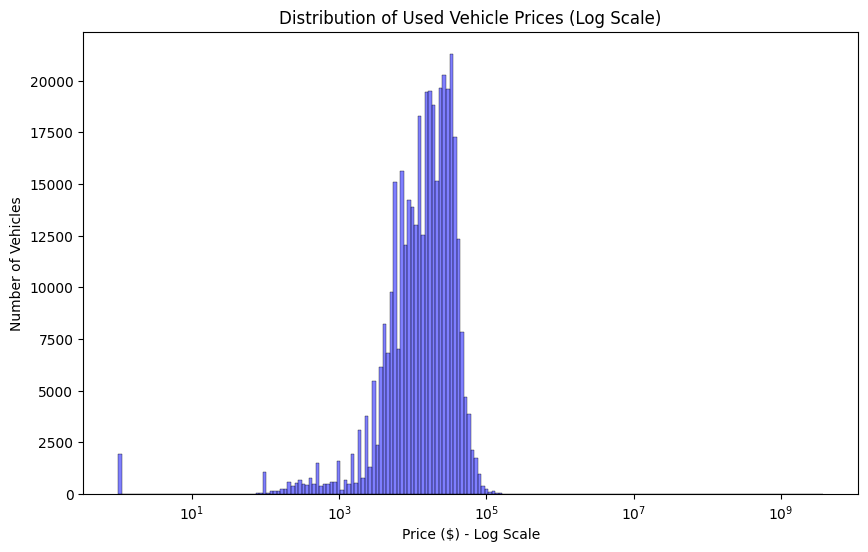

In [133]:
# Get an idea of the price distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=vehicles, x='price', bins=200, kde=True, color='blue', log_scale=True)
plt.title('Distribution of Used Vehicle Prices (Log Scale)')
plt.xlabel('Price ($) - Log Scale')
plt.ylabel('Number of Vehicles')
plt.show()


A quick look at the extremes of our price distribution reveals some clear data entry errors: numerous cars priced at $0 (likely marketing scams), and others with absurdly high prices like $3,736,928,711 (likely a phone number in the wrong field), or $1,234,567,890 (likely just careless input). To ensure our model learns from realistic market values, we will filter these out. 

We will use the IQR method to get rid of the outliers.

In [134]:
# check the outliers
print(vehicles.sort_values('price').head(100))
print(vehicles.sort_values('price').tail(100))

                id        region  price    year   manufacturer  \
335266  7307704873  philadelphia      0  2012.0       infiniti   
97994   7316671228  jacksonville      0  2016.0           ford   
97995   7316671091  jacksonville      0  2016.0  mercedes-benz   
97996   7316670635  jacksonville      0  2017.0         toyota   
356355  7304587188     knoxville      0  2008.0         nissan   
...            ...           ...    ...     ...            ...   
356248  7305532200     knoxville      0  2017.0          rover   
98338   7315296016  jacksonville      0  2016.0      chevrolet   
98217   7315738654  jacksonville      0  2011.0          dodge   
98219   7315737996  jacksonville      0  2011.0          dodge   
356247  7305532221     knoxville      0  2018.0          acura   

                      model  condition    cylinders fuel  odometer  \
335266             g37x awd        NaN          NaN  gas  131922.0   
97994                 f-150        NaN          NaN  NaN       NaN 

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [135]:
# handle missing data
# Drop the 'size' column (too much missing data)
# Drop ID and VIN columns that doesn't help with predicting prices
vehicles = vehicles.drop(['size', 'id', 'VIN'], axis = 1)

# drop rows where 'year' and 'odometer' are missing
vehicles = vehicles.dropna(subset=['year', 'odometer'])

# Impute condition column. 
# Create a mask to find rows where 'condition' is missing (or already filled as 'unknown')
missing_cond = vehicles['condition'].isna() | (vehicles['condition'] == 'unknown')
# If the title is 'salvage' or 'parts only', fill missing condition with 'salvage'
vehicles.loc[missing_cond & vehicles['title_status'].isin(['parts only', 'salvage']), 'condition'] = 'salvage'
# If the title is 'rebuilt', fill missing condition with 'fair'
vehicles.loc[missing_cond & (vehicles['title_status'] == 'rebuilt'), 'condition'] = 'fair'
# Check how many NAN or 'unknown' conditions are left
print(vehicles['condition'].value_counts())

# Impute car specs
# List of columns to impute based on the car's model
cols_to_impute = ['manufacturer', 'cylinders', 'fuel', 'drive']
# Group by 'model' and fill missing values with the mode of that group
for col in cols_to_impute:
    vehicles[col] = vehicles.groupby('model')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
    )
# Check how many values are still missing in those columns
print(vehicles[cols_to_impute].isnull().sum())


# Drop rows where key predictors are missing
vehicles = vehicles.dropna(subset=['manufacturer', 'fuel', 'title_status', 'transmission', 'drive'])

# Fill minor categoricals with 'other'
vehicles[['condition', 'cylinders', 'model', 'type', 'paint_color']] = vehicles[['condition', 'cylinders', 'model', 'type', 'paint_color']].fillna('other')

vehicles.info()

condition
good         121235
excellent     99765
like new      21178
fair           8707
salvage        2047
new            1303
Name: count, dtype: int64
manufacturer    20742
cylinders       42908
fuel             6574
drive           28513
dtype: int64
<class 'pandas.DataFrame'>
Index: 373279 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        373279 non-null  str    
 1   price         373279 non-null  int64  
 2   year          373279 non-null  float64
 3   manufacturer  373279 non-null  str    
 4   model         373279 non-null  str    
 5   condition     373279 non-null  str    
 6   cylinders     373279 non-null  str    
 7   fuel          373279 non-null  str    
 8   odometer      373279 non-null  float64
 9   title_status  373279 non-null  str    
 10  transmission  373279 non-null  str    
 11  drive         373279 non-null  str    
 12  type          373279 non-n

In [136]:
# feature encoding
# Drop ID and VIN columns that doesn't help with predicting prices 
# Already done in previous step

# Ordinal encoding for condition and cylinders
condition_mapping = {
    'salvage': 1,
    'fair': 2,
    'good': 3,
    'excellent': 4,
    'like new': 5,
    'new': 6,
    'other': 0
}
cylinders_mapping = {
    '3 cylinders': 3,
    '4 cylinders': 4,
    '5 cylinders': 5,
    '6 cylinders': 6,
    '8 cylinders': 8,
    '10 cylinders': 10,
    '12 cylinders': 12,
    'other': 0
}
vehicles['condition'] = vehicles['condition'].map(condition_mapping)
vehicles['cylinders'] = vehicles['cylinders'].map(cylinders_mapping)
# Peek at the data to make sure it worked
print(vehicles[['condition', 'cylinders']].head())


# Change year to car_age
current_year = datetime.datetime.now().year
vehicles['car_age'] = current_year - vehicles['year']
vehicles = vehicles.drop(columns=['year'])
# Peek at the new column alongside the price
print(vehicles[['car_age', 'price']].head())

    condition  cylinders
27          3          8
28          3          8
29          3          8
30          3          8
31          4          6
    car_age  price
27     12.0  33590
28     16.0  22590
29      6.0  39590
30      9.0  30990
31     13.0  15000


In [137]:
# We will do one hot encoding and target encoding in the model pipeline. 
# All code is commented out.

# Target Encoding learns from `price` — fitting it on the full dataset before splitting
# leaks test data into training data. OHE is leakage-safe but belongs in the pipeline
# so `handle_unknown='ignore'` handles unseen categories at prediction time.
# Ordinal encoding uses a fixed mapping (no target dependency), so it's safe to apply upfront.

# # One hot encoding
# # List of columns for one hot encoding
# columns_to_ohe = ['fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
# # Apply One-Hot Encoding
# # Set drop_first=True to avoid duplicate data
# vehicles = pd.get_dummies(vehicles, columns=columns_to_ohe, drop_first=True)
# # Check the shape of our dataframe to see how many new columns we created!
# print(vehicles.shape)

# # Target encoding 
# # List of columns for target encoding
# columns_to_te = ['region', 'manufacturer', 'model']
# # Apply Target Encoding
# for col in columns_to_te:
#     # Calculate the average price for each category in the column
#     target_means = vehicles.groupby(col)['price'].mean()
    
#     # Map those average prices back over the text values
#     vehicles[col] = vehicles[col].map(target_means)

# # Peek at the data to see the new numerical values!
# print(vehicles[columns_to_te].head())

In [138]:
# Check if our vehicles data frame is in good shape 
print("Vehicles shape:", vehicles.shape)
vehicles.head()
# no missing values
print("Still missing value:", sum(vehicles.isnull().sum()))

Vehicles shape: (373279, 15)
Still missing value: 0


Price range after IQR filter: $666 — $228,208
Vehicles shape (336215, 15)
Lowest price after removing outliers:  669
Highest price after removing outliers:  227995


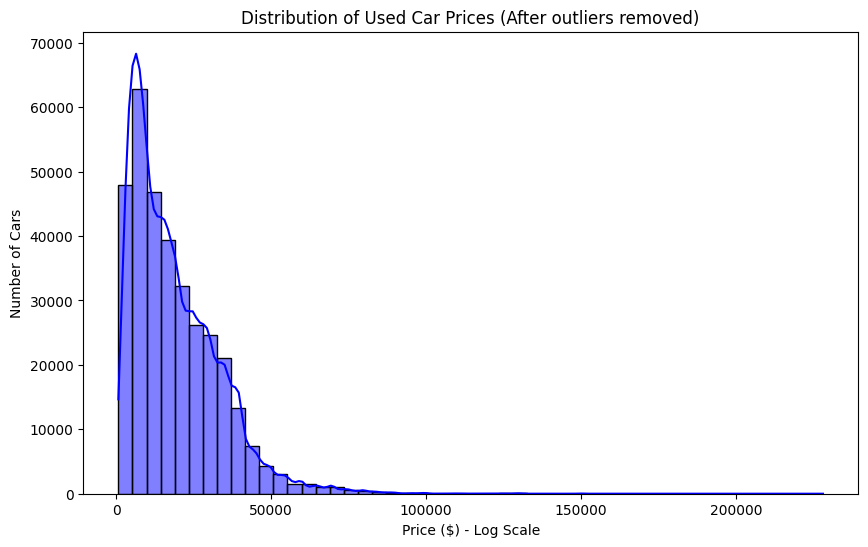

In [139]:
# Apply IQR on log-transformed prices to handle the right-skewed distribution
log_prices = np.log1p(vehicles['price'])

Q1 = log_prices.quantile(0.25)
Q3 = log_prices.quantile(0.75)
IQR = Q3 - Q1

lower_bound = np.expm1(Q1 - 1.5 * IQR)
upper_bound = np.expm1(Q3 + 1.5 * IQR)

print(f"Price range after IQR filter: ${lower_bound:,.0f} — ${upper_bound:,.0f}")

vehicles = vehicles[(vehicles['price'] >= lower_bound) & (vehicles['price'] <= upper_bound)]

# check the shape 
print("Vehicles shape", vehicles.shape)

# check the price distribution again
print("Lowest price after removing outliers: ", min(vehicles['price']))
print("Highest price after removing outliers: ", max(vehicles['price']))

plt.figure(figsize=(10, 6))
sns.histplot(data=vehicles, x='price', bins=50, kde=True, color='blue', log_scale=False)
plt.title('Distribution of Used Car Prices (After outliers removed)')
plt.xlabel('Price ($) - Log Scale')
plt.ylabel('Number of Cars')
plt.show()

Cars above $80k: 987 (0.29% of dataset)
Vehicles shape (335228, 15)


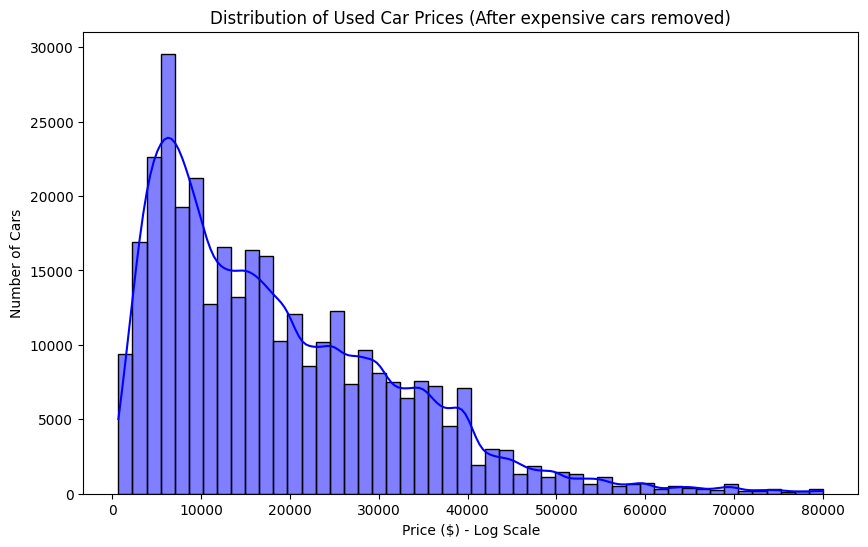

In [140]:
# Cars over $80,000 only makes up 0.3% of all data. They are more noises than info. 
# We will drop those. 
above_80k = (vehicles['price'] >= 80_000).sum()
total = len(vehicles)
print(f"Cars above $80k: {above_80k} ({above_80k/total*100:.2f}% of dataset)")

vehicles = vehicles[vehicles['price'] < 80_000]

# check the shape 
print("Vehicles shape", vehicles.shape)

# check the price distribution again
plt.figure(figsize=(10, 6))
sns.histplot(data=vehicles, x='price', bins=50, kde=True, color='blue', log_scale=False)
plt.title('Distribution of Used Car Prices (After expensive cars removed)')
plt.xlabel('Price ($) - Log Scale')
plt.ylabel('Number of Cars')
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [141]:
# Sample step to run faster during testing. 
# vehicles = vehicles.sample(n=50_000, random_state=42).reset_index(drop=True)
# print("Sampled shape:", vehicles.shape)

In [142]:
# split training and testing data
X = vehicles.drop('price', axis=1)
y = vehicles['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

# Define which columns get which treatment
te_cols = ['region', 'manufacturer', 'model', 'state']
ohe_cols = ['fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']
numeric_cols = ['car_age', 'odometer']

# Build the ColumnTransformer 
col_transformer = ColumnTransformer(
    transformers=[
        ('target_encode', TargetEncoder(smooth=10, target_type='continuous'), te_cols),
        ('one_hot', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
        ('scale_and_poly', Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler())
        ]), numeric_cols)
    ],
    remainder='passthrough'
)

# Build several pipelines
model_candidates = {
    'Linear': LinearRegression(),
    'Ridge':  Ridge(),
    'Lasso':  Lasso(),
}

pipelines = {}
cv_results = {}
for name, reg in model_candidates.items():
    pipe = Pipeline([
        ('transformer', col_transformer),
        ('regression_model', reg)
    ])
    pipelines[name] = pipe
    # Baseline comparison only — cross_val_score with default hyperparameters to get a rough
    # sense of which model family is worth tuning. GridSearchCV will replace this for final results.
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    cv_results[name] = rmse_scores
    print(f"{name:>10}  RMSE mean: ${rmse_scores.mean():>8,.2f}  RMSE std: ${rmse_scores.std():>5,.2f}")


    Linear  mean: $7,073.48  std: $73.71
     Ridge  mean: $9,457.17  std: $62.96
     Lasso  mean: $7,022.88  std: $69.14


In [155]:
# GridSearchCV to find the best hyperparameter for Ridge and Lasso
# Linear has no hyperparameters to tune so we skip it

param_grids = {
    'Ridge': {'regression_model__alpha': [0.01, 0.1, 1, 10, 100, 1000, 10000]},
    'Lasso': {'regression_model__alpha': [0.01, 0.1, 1, 10, 100, 1000, 10000]},
}

best_models = {}
for name, param_grid in param_grids.items():
    grid_search = GridSearchCV(
        pipelines[name], param_grid,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    best_rmse = -grid_search.best_score_
    best_alpha = grid_search.best_params_['regression_model__alpha']
    print(f"{name:>10} Best alpha: {best_alpha:>3} Best Training RMSE: ${best_rmse:>8,.2f}")

     Ridge Best alpha:   1 Best Training RMSE: $9,457.17
     Lasso Best alpha: 0.1 Best Training RMSE: $7,022.75


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [167]:
# Use testing data set to validate which model performs better
for name in ['Ridge', 'Lasso']:
    y_pred = best_models[name].predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name:<8} Test RMSE: ${rmse:>8,.2f}   Test R_Squared:{r2:>5.2f}")

# We can tell from the results that the Lasso model is much better. 


Ridge    Test RMSE: $9,336.94   Test R_Squared: 0.54
Lasso    Test RMSE: $6,927.49   Test R_Squared: 0.74


In [169]:
# Get feature names from the pipeline transformer
lasso_coefs = best_models['Lasso'].named_steps['regression_model'].coef_
lasso_df = pd.DataFrame({'feature': feature_names, 'coef': lasso_coefs})
lasso_df['abs_coef'] = lasso_df['coef'].abs()
print(f"Lasso: {(lasso_coefs != 0).sum()} / {len(lasso_coefs)} features kept")
print(lasso_df[lasso_coefs != 0].sort_values('abs_coef', ascending=False))


Lasso: 48 / 48 features kept
                             feature          coef      abs_coef
41           scale_and_poly__car_age -12362.562110  12362.562110
43         scale_and_poly__car_age^2   9212.698163   9212.698163
5                  one_hot__fuel_gas  -8377.867863   8377.867863
6               one_hot__fuel_hybrid  -7393.495095   7393.495095
7                one_hot__fuel_other  -7355.851064   7355.851064
10  one_hot__title_status_parts only  -7075.243479   7075.243479
42          scale_and_poly__odometer  -6483.090883   6483.090883
45        scale_and_poly__odometer^2   5733.937339   5733.937339
4             one_hot__fuel_electric  -5495.245589   5495.245589
9      one_hot__title_status_missing  -5021.590339   5021.590339
12     one_hot__title_status_salvage  -4498.683850   4498.683850
18         one_hot__type_convertible   4156.081263   4156.081263
11     one_hot__title_status_rebuilt  -3839.684123   3839.684123
22             one_hot__type_offroad   2813.205459   2813.205

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Key Findings Report: What Drives Used Car Prices?

This report is based on a a model trained by more than 300,000 listings.

#### 1. Car Age is the #1 Price Driver
Older vehicles lose value significantly with every passing year. This reflects
standard depreciation and is the single strongest predictor in our model.

**Recommendation:** Prioritize sourcing vehicles newer cars.

#### 2. Mileage (Odometer) is the #2 Price Driver
High mileage strongly depresses price, independent of age. A low-mileage older car can still have a good price.

**Recommendation:** When evaluating two similar vehicles, favor the one with lower odometer readings — buyers are willing to pay a premium for it.

#### 3. Diesel Vehicles Command a Massive Premium
Compared to the baseline of a Diesel engine, all other fuel types are significantly cheaper. 

* **Recommendation:** Source more Diesel vehicles.

#### 4. Clean Titles are Non-Negotiable for Premium Pricing
The model clearly punishes anything less than a clean title. 
* **Recommendation:** Avoid compromised titles unless acquiring them at a severe discount. 

#### 5. Specialty Vehicle Types Hold Value Better Than Sedans/SUVs
Certain body types carry distinct premiums over standard commuter cars. These types are:
* `Convertible`
* `Offroad`
* `Coupe`
* `Truck / Pickup`
* **Recommendation:** Fun or utility-focused body styles (convertibles, off-roaders, trucks) command measurable premiums. Source more of these body styles.

### Limitations
- Pricing also depends on local market conditions, negotiation, and timing —
  factors not captured in this dataset
- Rare or exotic vehicles (< 0.3% of data) were excluded as outliers
